**Name:** Manali Vijay Gaikwad

**PRN:** 2324000509

**TY(AIML) DIV:A-58**

**Experiment No. 8 Kidney Cancer Detection using VGG16,VGG19, ResNET Comparative Analysis , Transfer Learning**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


In [ ]:
train_path = "/content/drive/My Drive/Deep Learning Lab/data 4/Training_images"
test_path  = "/content/drive/My Drive/Deep Learning Lab/data 4/Test_images"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 171 images belonging to 5 classes.
Found 106 images belonging to 5 classes.


In [ ]:
# STEP 7: Build VGG16 Model

base_model_vgg16 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_vgg16.layers:
    layer.trainable = False

model_vgg16 = Sequential()

model_vgg16.add(base_model_vgg16)

# 3x3 Filter CNN Layer
model_vgg16.add(Conv2D(32,(3,3),activation='relu'))

# MaxPooling 2x2
model_vgg16.add(MaxPooling2D(pool_size=(2,2)))

model_vgg16.add(Flatten())

model_vgg16.add(Dense(128,activation='relu'))
model_vgg16.add(Dropout(0.5))

model_vgg16.add(Dense(5,activation='softmax'))

In [ ]:
model_vgg16.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model_vgg16.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,333 (56.76 MB)

 Trainable params: 164,645 (643.14 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [ ]:
# Train VGG16
history_vgg16 = model_vgg16.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 9s/step - accuracy: 0.2515 - loss: 1.6952 - val_accuracy: 0.2170 - val_loss: 1.5923
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.2105 - loss: 1.6540 - val_accuracy: 0.3491 - val_loss: 1.5537
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3275 - loss: 1.5123 - val_accuracy: 0.3585 - val_loss: 1.5316
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3275 - loss: 1.4903 - val_accuracy: 0.3868 - val_loss: 1.5169
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4444 - loss: 1.4014 - val_accuracy: 0.4057 - val_loss: 1.4949


In [ ]:

# STEP 7: Build VGG19 Model


base_model_vgg19 = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_vgg19.layers:
    layer.trainable = False

model_vgg19 = Sequential()

model_vgg19.add(base_model_vgg19)

model_vgg19.add(Conv2D(32,(3,3),activation='relu'))
model_vgg19.add(MaxPooling2D(pool_size=(2,2)))

model_vgg19.add(Flatten())

model_vgg19.add(Dense(128,activation='relu'))
model_vgg19.add(Dropout(0.5))

model_vgg19.add(Dense(5,activation='softmax'))

model_vgg19.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model_vgg19.summary())

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,189,029 (77.02 MB)

 Trainable params: 164,645 (643.14 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

None


In [ ]:

# Train VGG19
history_vgg19 = model_vgg19.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)


Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2573 - loss: 1.6394 - val_accuracy: 0.0849 - val_loss: 1.5929
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4152 - loss: 1.4277 - val_accuracy: 0.1604 - val_loss: 1.5192
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5263 - loss: 1.2370 - val_accuracy: 0.2264 - val_loss: 1.5151
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6842 - loss: 0.9782 - val_accuracy: 0.3208 - val_loss: 1.5070
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6667 - loss: 0.8829 - val_accuracy: 0.2453 - val_loss: 1.6652
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6959 - loss: 0.7962 - val_accuracy: 0.2170 - val_loss: 1.7940
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7427 - loss: 0.6573 - val_accuracy: 0.3208 - val_loss: 1.5735
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7193 - loss: 0.6032 - val_accuracy: 0.2264 - val_loss: 2.1246
Epoch 9/15
6/6 

In [ ]:
# STEP 7: Build ResNet50 Model


base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_resnet.layers:
    layer.trainable = False

model_resnet = Sequential()

model_resnet.add(base_model_resnet)

model_resnet.add(Conv2D(32,(3,3),activation='relu'))
model_resnet.add(MaxPooling2D(pool_size=(2,2)))

model_resnet.add(Flatten())

model_resnet.add(Dense(128,activation='relu'))
model_resnet.add(Dropout(0.5))

model_resnet.add(Dense(5,activation='softmax'))

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model_resnet.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 32)       │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,194,725 (92.30 MB)

 Trainable params: 607,013 (2.32 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [ ]:
# Train ResNet50

history_resnet = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.1579 - loss: 2.4084 - val_accuracy: 0.4057 - val_loss: 1.6787
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2515 - loss: 1.7048 - val_accuracy: 0.3302 - val_loss: 1.6016
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3684 - loss: 1.5230 - val_accuracy: 0.3774 - val_loss: 1.5338
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3860 - loss: 1.4572 - val_accuracy: 0.4340 - val_loss: 1.4604
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3684 - loss: 1.3974 - val_accuracy: 0.4340 - val_loss: 1.4280
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4795 - loss: 1.2093 - val_accuracy: 0.4340 - val_loss: 1.3691
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4444 - loss: 1.2252 - val_accuracy: 0.4340 - val_loss: 1.3480
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4211 - loss: 1.1793 - val_accuracy: 0.3774 - val_loss: 1.4118
Epoch 9/15
6/6

In [ ]:
# STEP 8: Evaluate Models

print("VGG16 Evaluation")
vgg16_result = model_vgg16.evaluate(test_data)

print("VGG19 Evaluation")
vgg19_result = model_vgg19.evaluate(test_data)

print("ResNet50 Evaluation")
resnet_result = model_resnet.evaluate(test_data)

VGG16 Evaluation
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 569ms/step - accuracy: 0.4057 - loss: 1.4949
VGG19 Evaluation
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.3019 - loss: 2.0892
ResNet50 Evaluation
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.4623 - loss: 1.1892


In [ ]:
# STEP 9: Predict Test Data

predictions = model_vgg16.predict(test_data)

print(predictions)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step
[[0.13695039 0.14007927 0.25349838 0.27333087 0.19614117]
 [0.16106154 0.15953198 0.23944424 0.2356871  0.20427516]
 [0.15756205 0.18434693 0.22786935 0.24089141 0.18933024]
 [0.22479679 0.11762723 0.18338051 0.21005973 0.2641357 ]
 [0.13742921 0.10738847 0.2425179  0.24553752 0.26712698]
 [0.11986562 0.18396507 0.2361203  0.28543276 0.17461623]
 [0.22259623 0.10622697 0.18760914 0.20589946 0.27766827]
 [0.14914328 0.1684569  0.1996892  0.26338074 0.21932988]
 [0.15336213 0.1302267  0.15627317 0.20198765 0.35815033]
 [0.15249981 0.17756507 0.18380435 0.27504677 0.21108408]
 [0.14227246 0.18885227 0.21499525 0.24859418 0.20528574]
 [0.17627077 0.13303266 0.22043993 0.25227663 0.21798004]
 [0.11412115 0.15250249 0.27373058 0.24208075 0.21756506]
 [0.14105445 0.17483145 0.22992085 0.26676318 0.18743007]
 [0.13490495 0.13586846 0.27682132 0.28235355 0.17005171]
 [0.17534079 0.10461566 0.22832738 0.21954596 0.27217025]
 [0.14593951 0.10344327 0.1378784

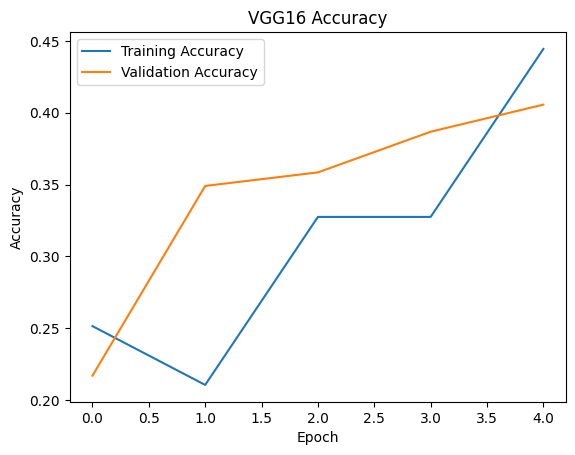

In [ ]:

# STEP 10 & 11: Plot Accuracy and Loss Graphs

plt.plot(history_vgg16.history['accuracy'],label='Training Accuracy')
plt.plot(history_vgg16.history['val_accuracy'],label='Validation Accuracy')

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

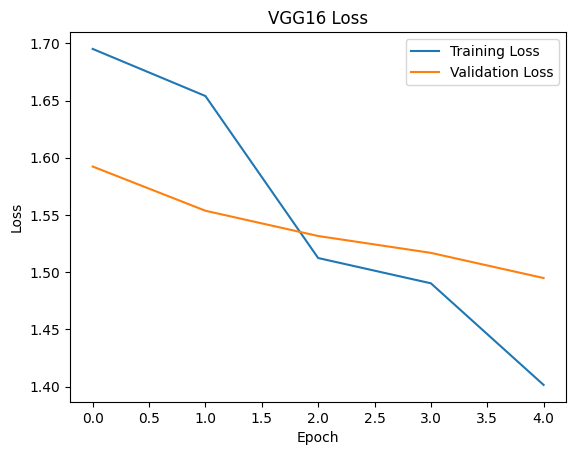

In [ ]:
plt.plot(history_vgg16.history['loss'],label='Training Loss')
plt.plot(history_vgg16.history['val_loss'],label='Validation Loss')

plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:

# STEP 12: Test Random Image


img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade2/Image_5421.jpg"

img = image.load_img(img_path,target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

img_array = img_array / 255.0

result = model_vgg16.predict(img_array)

if result[0][0] > 0.5:
    print("Cancerous Kidney")
else:
    print("Normal Kidney")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Normal Kidney


In [ ]:


img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade2/Image_5421.jpg"

img = image.load_img(img_path,target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

img_array = img_array / 255.0

result = model_vgg19.predict(img_array)

if result[0][0] > 0.5:
    print("Cancerous Kidney")
else:
    print("Normal Kidney")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Normal Kidney


In [ ]:


img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade2/Image_5421.jpg"

img = image.load_img(img_path,target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

img_array = img_array / 255.0

result = model_resnet.predict(img_array)

if result[0][0] > 0.5:
    print("Cancerous Kidney")
else:
    print("Normal Kidney")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Normal Kidney


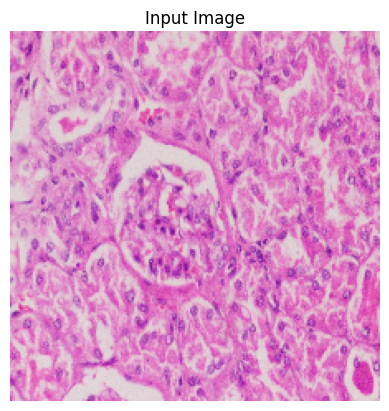

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction: Grade4


In [ ]:

img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade0/Image_6213.jpg"
img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.title(f"Input Image")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)


pred = model_vgg16.predict(img_array)
class_index = np.argmax(pred)

classes = list(train_data.class_indices.keys())

print(f"Prediction:", classes[class_index])

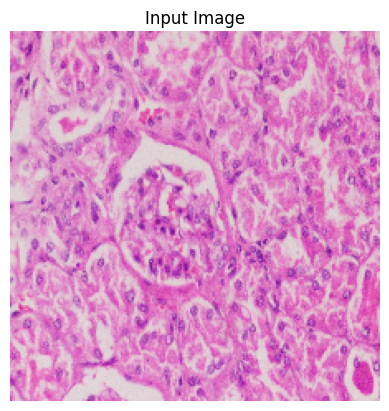

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction: Grade2


In [ ]:

img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade0/Image_6213.jpg"
img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.title(f"Input Image")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)


pred = model_vgg19.predict(img_array)
class_index = np.argmax(pred)

classes = list(train_data.class_indices.keys())

print(f"Prediction:", classes[class_index])

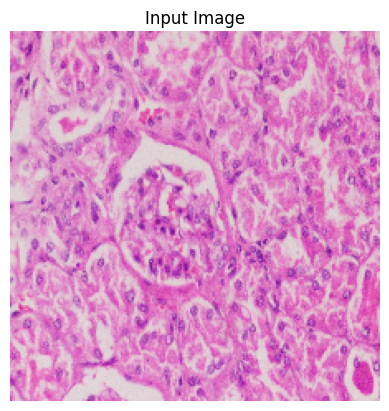

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: Grade3


In [ ]:

img_path = "/content/drive/MyDrive/Deep Learning Lab/data 4/Test_images/Grade0/Image_6213.jpg"
img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.title(f"Input Image")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)


pred = model_resnet.predict(img_array)
class_index = np.argmax(pred)

classes = list(train_data.class_indices.keys())

print(f"Prediction:", classes[class_index])

In [1]:
# Case Study:- Medical Image Classification – Chest X-ray Disease Detection Problem Statement Early and accurate detection of chest diseases (Pneumonia, COVID-19, Normal) from
# X-ray images. Dataset ● Chest X-ray (NIH / Kaggle) ● Limited, imbalanced medical data Models Used ● VGG16 (pretrained on ImageNet) ● VGG19 (pretrained on ImageNet) ● ResNet-50
#  (pretrained on ImageNet)

import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# STEP 3: DATASET PATH
train_path = "/content/drive/MyDrive/Deep Learning Lab/archive/train"
test_path  = "/content/drive/MyDrive/Deep Learning Lab/archive/test"

In [4]:
# STEP 4: CHECK DATASET FOLDERS
import os
print(os.listdir(train_path))
print(os.listdir(test_path))

['NORMAL', 'PNEUMONIA', 'COVID19', 'TURBERCULOSIS']
['NORMAL', 'TURBERCULOSIS', 'PNEUMONIA', 'COVID19']


In [5]:
# STEP 5: IMAGE PREPROCESSING + AUGMENTATION
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
# STEP 6: LOAD TRAIN AND TEST DATA
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1079 images belonging to 4 classes.
Found 184 images belonging to 4 classes.


In [7]:
# STEP 7: LOAD VGG16 MODEL
base_model_vgg16 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_vgg16.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# STEP 8: BUILD VGG16 MODEL

model_vgg16 = Sequential()

model_vgg16.add(base_model_vgg16)

# 3x3 FILTER
model_vgg16.add(Conv2D(32,(3,3),activation='relu'))

# MAXPOOLING 2x2
model_vgg16.add(MaxPooling2D(pool_size=(2,2)))

model_vgg16.add(Flatten())

model_vgg16.add(Dense(128,activation='relu'))

model_vgg16.add(Dropout(0.5))

# 4 CLASSES
model_vgg16.add(Dense(4,activation='softmax'))

In [17]:
# STEP 9: COMPILE MODEL
model_vgg16.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model_vgg16.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,204 (56.76 MB)

 Trainable params: 164,516 (642.64 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [18]:
# STEP 10: TRAIN VGG16 MODEL

history_vgg16 = model_vgg16.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 478s 14s/step - accuracy: 0.4930 - loss: 1.1208 - val_accuracy: 0.1467 - val_loss: 2.1274
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6506 - loss: 0.7645 - val_accuracy: 0.2989 - val_loss: 2.4719
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.7062 - loss: 0.6083 - val_accuracy: 0.3315 - val_loss: 2.6386
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7998 - loss: 0.4649 - val_accuracy: 0.3641 - val_loss: 3.0131
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8628 - loss: 0.3660 - val_accuracy: 0.3696 - val_loss: 3.3222


In [19]:
# STEP 11: LOAD VGG19 MODEL
base_model_vgg19 = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_vgg19.layers:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
# STEP 11: LOAD VGG19 MODEL
base_model_vgg19 = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_vgg19.layers:
    layer.trainable = False

# STEP 12: BUILD VGG19 MODEL
model_vgg19 = Sequential()

model_vgg19.add(base_model_vgg19)

model_vgg19.add(Conv2D(32,(3,3),activation='relu'))

model_vgg19.add(MaxPooling2D(pool_size=(2,2)))

model_vgg19.add(Flatten())

model_vgg19.add(Dense(128,activation='relu'))

model_vgg19.add(Dropout(0.5))

model_vgg19.add(Dense(4,activation='softmax'))

In [21]:
# STEP 13: COMPILE + TRAIN VGG19


model_vgg19.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg19 = model_vgg19.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6877 - loss: 0.6790 - val_accuracy: 0.3750 - val_loss: 3.9974
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8703 - loss: 0.3141 - val_accuracy: 0.3696 - val_loss: 4.7082
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9212 - loss: 0.2218 - val_accuracy: 0.2989 - val_loss: 4.4912
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9314 - loss: 0.1976 - val_accuracy: 0.3859 - val_loss: 5.6790
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9231 - loss: 0.2030 - val_accuracy: 0.3967 - val_loss: 5.7007


In [22]:

# STEP 14: LOAD RESNET50 MODEL


base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_resnet.layers:
    layer.trainable = False

# STEP 15: BUILD RESNET50 MODEL


model_resnet = Sequential()

model_resnet.add(base_model_resnet)

model_resnet.add(Conv2D(32,(3,3),activation='relu'))

model_resnet.add(MaxPooling2D(pool_size=(2,2)))

model_resnet.add(Flatten())

model_resnet.add(Dense(128,activation='relu'))

model_resnet.add(Dropout(0.5))

model_resnet.add(Dense(4,activation='softmax'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
# ==========================================================
# STEP 16: COMPILE + TRAIN RESNET50
# ==========================================================

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5487 - loss: 1.0072 - val_accuracy: 0.0000e+00 - val_loss: 3.2649
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5885 - loss: 0.7091 - val_accuracy: 0.0000e+00 - val_loss: 4.3077
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 992ms/step - accuracy: 0.5709 - loss: 0.6980 - val_accuracy: 0.0000e+00 - val_loss: 4.1148
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 975ms/step - accuracy: 0.5885 - loss: 0.6823 - val_accuracy: 0.0000e+00 - val_loss: 4.5953
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 978ms/step - accuracy: 0.6061 - loss: 0.6577 - val_accuracy: 0.1250 - val_loss: 4.1602


In [24]:
# ==========================================================
# STEP 17: EVALUATE MODELS
# ==========================================================

print("VGG16 Evaluation")
model_vgg16.evaluate(test_data)

print("VGG19 Evaluation")
model_vgg19.evaluate(test_data)

print("ResNet50 Evaluation")
model_resnet.evaluate(test_data)

VGG16 Evaluation
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3696 - loss: 3.3222
VGG19 Evaluation
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 606ms/step - accuracy: 0.3967 - loss: 5.7007
ResNet50 Evaluation
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.1250 - loss: 4.1602


[4.160150051116943, 0.125]

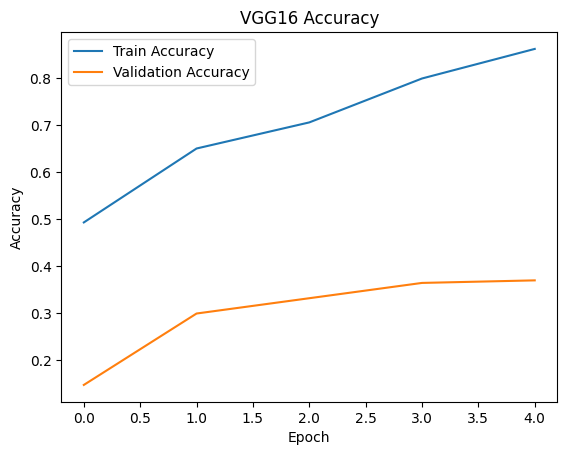

In [25]:
# ==========================================================
# STEP 18: PLOT ACCURACY GRAPH
# ==========================================================

plt.plot(history_vgg16.history['accuracy'],label='Train Accuracy')

plt.plot(history_vgg16.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

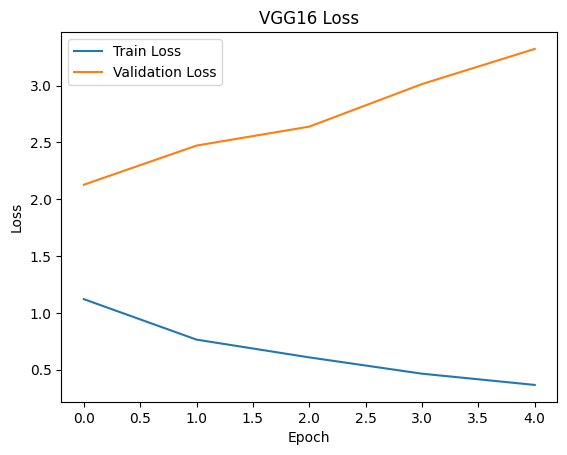

In [26]:
# ==========================================================
# STEP 19: PLOT LOSS GRAPH
# ==========================================================

plt.plot(history_vgg16.history['loss'],
         label='Train Loss')

plt.plot(history_vgg16.history['val_loss'],
         label='Validation Loss')

plt.title("VGG16 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [27]:
# ==========================================================
# STEP 20: CONFUSION MATRIX
# ==========================================================

Y_pred = model_vgg16.predict(test_data)

y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred)

print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step
[[ 68   0   6]
 [109   0   1]
 [  0   0   0]]


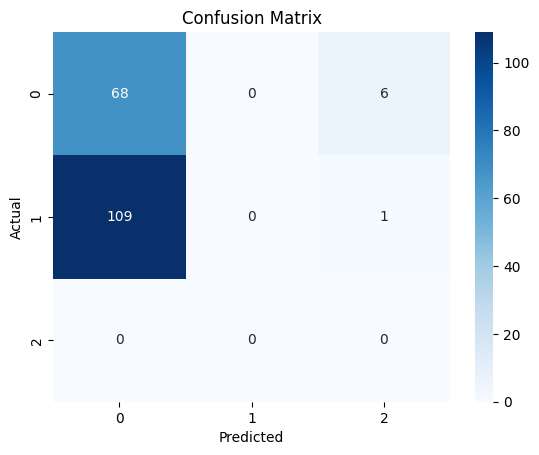

In [28]:
# ==========================================================
# STEP 21: CONFUSION MATRIX HEATMAP
# ==========================================================

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [29]:
# ==========================================================
# STEP 22: CLASSIFICATION REPORT
# ==========================================================

print(classification_report(
    test_data.classes,
    y_pred
))

              precision    recall  f1-score   support

           0       0.38      0.92      0.54        74
           2       0.00      0.00      0.00       110
           3       0.00      0.00      0.00         0

    accuracy                           0.37       184
   macro avg       0.13      0.31      0.18       184
weighted avg       0.15      0.37      0.22       184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
# ==========================================================
# STEP 23: TEST RANDOM IMAGE
# ==========================================================


In [ ]:
# This cell is now redundant as its content has been moved to cell vnWbEQuTfq1O


In [ ]:
# ==========================================================
# STEP 23, 24, 26, 27: TEST RANDOM IMAGE AND FINAL OUTPUT
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/sample_xray.jpg"

# Load Image
img = image.load_img(
    img_path,
    target_size=(224,224)
)

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array = img_array / 255.0

# Predict Image
prediction = model_vgg16.predict(img_array)

print("Raw prediction:", prediction)

# Final Output
classes = ['COVID','NORMAL','PNEUMONIA', 'TURBERCULOSIS']
result = classes[np.argmax(prediction)]

print("Predicted Disease :", result)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/sample_xray.jpg'

In [14]:
# This cell is now redundant as its content has been moved to cell vnWbEQuTfq1O


NameError: name 'prediction' is not defined